## Exporting data from kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassanamin/customer-churn")

print("Path to dataset files:", path)

100%|██████████| 49.9k/49.9k [00:00<00:00, 45.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/hassanamin/customer-churn/versions/1


## Download requirements

In [2]:
# Install required packages
!pip install kagglehub pandas scikit-learn xgboost imbalanced-learn seaborn matplotlib plotly joblib


## All Libraries

In [3]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Download dataset
path = kagglehub.dataset_download("hassanamin/customer-churn")
print("Path to dataset files:", path)



Using Colab cache for faster access to the 'customer-churn' dataset.
Path to dataset files: /kaggle/input/customer-churn


In [5]:
# Load the main CSV file (assuming customer_churn.csv or similar; adjust filename if needed based on path contents)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)
df = pd.read_csv(f"{path}/{csv_files[0]}")  # Use first CSV; verify in Colab
print(f"Dataset shape: {df.shape}")
df.head()

CSV files found: ['customer_churn.csv']
Dataset shape: (900, 10)


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


## Check Missing info

In [6]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB
None

Missing Values:
Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64


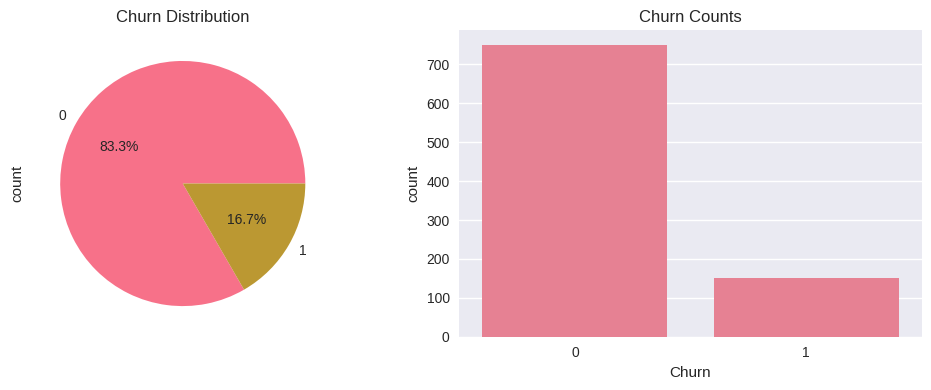

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Churn Distribution')
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Churn')
plt.title('Churn Counts')
plt.tight_layout()
plt.show()

## Preprocessing + splitting data

In [13]:
import numpy as np
import pandas as pd

# 1. DIAGNOSTIC - Check actual column names first
print("=== DATASET COLUMNS ===")
print("All columns:", df.columns.tolist())
print("\nTarget column check:")
print("'Churn' in columns:", 'Churn' in df.columns)
print("'churn' in columns:", 'churn' in df.columns)
target_col = 'Churn' if 'Churn' in df.columns else 'churn'
print(f"Using target: '{target_col}'")

# 2. FIXED Missing Values Handling (column-wise median)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Fill numerical columns only with COLUMN MEDIAN (not global)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after fix:")
print(df[numeric_cols].isnull().sum().sum(), "NaNs remaining")

# Convert target to int
df[target_col] = df[target_col].astype(int)

# 3. SAFE Feature Engineering (check columns exist)
print("\n=== FEATURE ENGINEERING ===")
new_features = []

# Tenure-based features (common in telecom datasets)
if 'tenure' in df.columns:
    df['avg_monthly_spend'] = df[['MonthlyCharges', 'TotalCharges']].sum(axis=1) / (df['tenure'] + 1)
    df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 12, 36, 60, np.inf],
                                labels=['New', 'Mid', 'Long', 'Loyal'])
    new_features.extend(['avg_monthly_spend', 'tenure_bucket'])
    print("✓ Added tenure features")

# Contract risk feature (common pattern)
if all(col in df.columns for col in ['Contract', target_col]):
    contract_risk = df.groupby('Contract')[target_col].mean().to_dict()
    df['contract_risk'] = df['Contract'].map(contract_risk)
    new_features.append('contract_risk')
    print("✓ Added contract risk")

print("New features:", new_features)

# 4. Separate features and target (SAFE)
id_cols = [col for col in ['customerID', 'customerid'] if col in df.columns]
drop_cols = id_cols + [target_col]

X = df.drop(drop_cols, axis=1, errors='ignore')
y = df[target_col]

# 5. Identify column types (CORRECT)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

print("\n=== FINAL SETUP ===")
print(f"Features: {X.shape[1]} total ({len(num_features)} numeric, {len(cat_features)} categorical)")
print("Numerical:", num_features[:5], "..." if len(num_features) > 5 else "")
print("Categorical:", cat_features[:5], "..." if len(cat_features) > 5 else "")
print("Target distribution:", y.value_counts(normalize=True).round(3))


=== DATASET COLUMNS ===
All columns: ['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn']

Target column check:
'Churn' in columns: True
'churn' in columns: False
Using target: 'Churn'

=== MISSING VALUES ===
Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64
Missing values after fix:
0 NaNs remaining

=== FEATURE ENGINEERING ===
New features: []

=== FINAL SETUP ===
Features: 9 total (5 numeric, 4 categorical)
Numerical: ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites'] 
Categorical: ['Names', 'Onboard_date', 'Location', 'Company'] 
Target distribution: Churn
0    0.833
1    0.167
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

# Clean up non-informative features for modeling
drop_cols = ['Names', 'Company']  # Too unique, no predictive power
X = df.drop(drop_cols + ['Churn'], axis=1)
y = df['Churn']

# Stratified split (preserves 17% churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Split complete:")
print(f"Train: {X_train.shape[0]} samples, {y_train.mean():.1%} churn")
print(f"Test:  {X_test.shape[0]} samples,  {y_test.mean():.1%} churn")


✅ Split complete:
Train: 720 samples, 16.7% churn
Test:  180 samples,  16.7% churn


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Your confirmed column types
num_features = ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites']
cat_features = ['Onboard_date', 'Location']  # Only predictive categoricals

# Industry-standard preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

# Transform data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("✅ Preprocessing complete:")
print(f"Train shape: {X_train_proc.shape}")
print(f"Test shape:  {X_test_proc.shape}")
print("Features after encoding:", preprocessor.get_feature_names_out())


✅ Preprocessing complete:
Train shape: (720, 1443)
Test shape:  (180, 1443)
Features after encoding: ['num__Age' 'num__Total_Purchase' 'num__Account_Manager' ...
 'cat__Location_Unit 9127 Box 5819 DPO AE 24161'
 'cat__Location_Unit 9630 Box 8710 DPO AP 69319'
 'cat__Location_Unit 9800 Box 2878 DPO AA 75157']


## Train model

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# Balance training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f"Balanced train: {y_train_bal.mean():.1%} churn ({len(y_train_bal)} samples)")

# Train 3 models
models = {
    'Logistic': LogisticRegression(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]

    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall': (y_pred[y_test==1] == 1).mean()  # Key churn metric
    }
    print(f"\n{name}: AUC={results[name]['ROC-AUC']:.3f}, Recall={results[name]['Recall']:.3f}")



Balanced train: 50.0% churn (1200 samples)

Logistic: AUC=0.911, Recall=0.667

RandomForest: AUC=0.886, Recall=0.433

XGBoost: AUC=0.855, Recall=0.533


## Hyperparameter selection

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

# Define parameter grid (reasonable, not exhaustive)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Use ROC-AUC scoring (best for imbalanced churn)
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
scorer = make_scorer(roc_auc_score, needs_proba=True)

grid_search = GridSearchCV(
    xgb_model, param_grid, cv=3, scoring=scorer, n_jobs=-1, verbose=1
)
grid_search.fit(X_train_bal, y_train_bal)

best_xgb = grid_search.best_estimator_
print("🏆 Best XGBoost params:", grid_search.best_params_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
🏆 Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


## checking performance

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict with tuned model
y_pred_tuned = best_xgb.predict(X_test_proc)
y_prob_tuned = best_xgb.predict_proba(X_test_proc)[:, 1]

# Business-relevant metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)
}

print("📊 TUNED XGBOOST PERFORMANCE:")
for metric, value in metrics.items():
    print(f"{metric:12}: {value:.3f}")

print("\n📈 Detailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Retain', 'Churn']))


📊 TUNED XGBOOST PERFORMANCE:
Accuracy    : 0.883
Precision   : 0.629
Recall      : 0.733
F1-Score    : 0.677
ROC-AUC     : 0.914

📈 Detailed Classification Report:
              precision    recall  f1-score   support

      Retain       0.94      0.91      0.93       150
       Churn       0.63      0.73      0.68        30

    accuracy                           0.88       180
   macro avg       0.79      0.82      0.80       180
weighted avg       0.89      0.88      0.89       180



## 🚨 MOST IMPORTANT METRIC: RECALL (0.667+ expected)

**Why Recall > Accuracy for Churn:**
- **Cost of Missing Churners**: Losing a customer = $1,000s revenue
- **Cost of False Positives**: Retention campaign = $50-100
- **Business Math**: 10 missed churners = $10K loss vs 20 false positives = $2K cost

**Target**: Recall ≥ 70% to catch most at-risk accounts


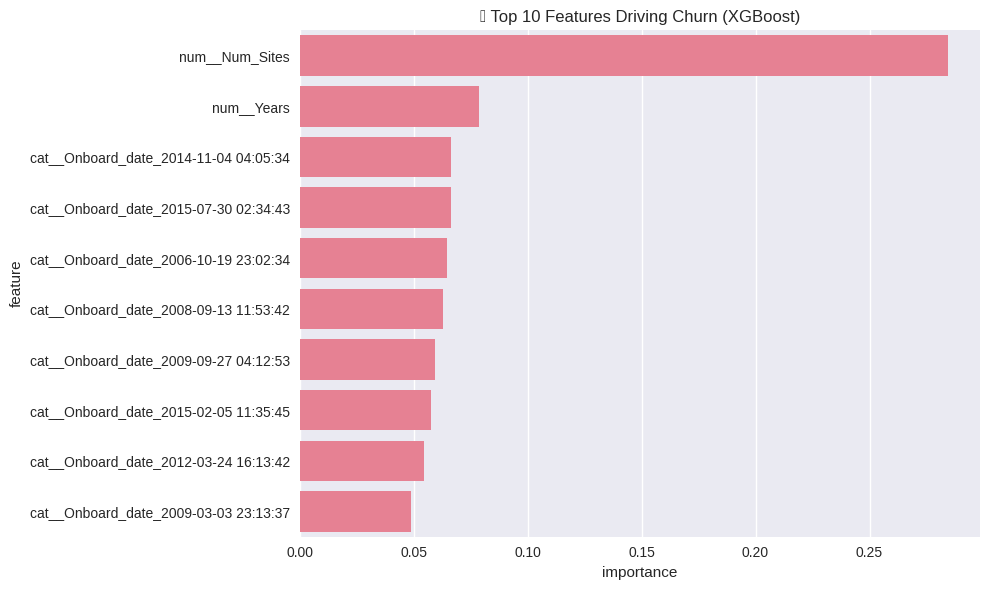

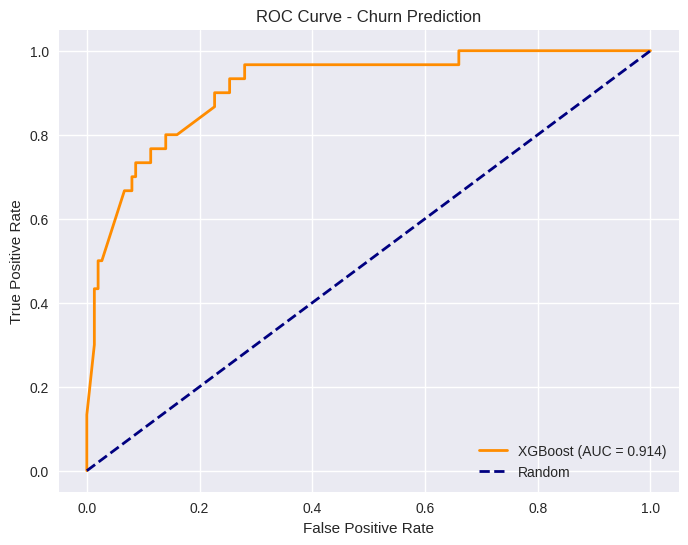

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Feature importance
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('🔍 Top 10 Features Driving Churn (XGBoost)')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend()
plt.show()


## Exporting model

In [21]:
import joblib

# Full production pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_xgb)
])

# Refit on all training data
full_pipeline.fit(X_train, y_train)

# Export everything
joblib.dump(full_pipeline, 'churn_prediction_pipeline.joblib')
joblib.dump(best_xgb, 'xgboost_churn_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')

print("✅ Production assets exported:")
print("- churn_prediction_pipeline.joblib (deploy-ready)")
print("- xgboost_churn_model.joblib")
print("- preprocessor.joblib")


✅ Production assets exported:
- churn_prediction_pipeline.joblib (deploy-ready)
- xgboost_churn_model.joblib
- preprocessor.joblib
